In [198]:
import scipy
import numpy as np
import pandas as pd
import re

Модули:

In [199]:
import numpy as np
from scipy import sparse as sp
from scipy.special import expit


class BaseSmoothOracle:
    """
    Базовый класс для реализации оракулов.
    """
    def func(self, w):
        """
        Вычислить значение функции в точке w.
        """
        raise NotImplementedError('Func oracle is not implemented.')

    def grad(self, w):
        """
        Вычислить значение градиента функции в точке w.
        """
        raise NotImplementedError('Grad oracle is not implemented.')


class BinaryLogistic(BaseSmoothOracle):
    """
    Оракул для задачи двухклассовой логистической регрессии.

    Оракул должен поддерживать l2 регуляризацию.
    """

    def __init__(self, l2_coef):
        """
        Задание параметров оракула.

        l2_coef - коэффициент l2 регуляризации
        """
        self.coef = l2_coef

    @staticmethod
    def make_dot(X, w):
        return X.dot(w) if sp.issparse(X) else X @ w

    @staticmethod
    def make_01(y):
        if np.array_equal(np.unique(y), np.array([-1, 1])):
            return (y + 1) / 2
        return y

    def l2_reg(self, w):
        if self.coef == 0:
            return 0, np.zeros_like(w)
        reg_val = 0.5 * self.coef * np.dot(w, w)
        reg_grad = self.coef * w
        return reg_val, reg_grad

    def func(self, X, y, w):
        """
        Вычислить значение функционала в точке w на выборке X с ответами y.

        X - scipy.sparse.csr_matrix или двумерный numpy.array

        y - одномерный numpy array

        w - одномерный numpy array
        """
        y = self.make_01(y)
        z = self.make_dot(X, w)
        reg_val, _ = self.l2_reg(w)
        loss = np.mean(np.logaddexp(0.0, z) - y * z)

        return float(loss + reg_val)

    def grad(self, X, y, w):
        """
        Вычислить градиент функционала в точке w на выборке X с ответами y.

        X - scipy.sparse.csr_matrix или двумерный numpy.array

        y - одномерный numpy array

        w - одномерный numpy array
        """
        y = self.make_01(y)
        z = self.make_dot(X, w)
        p = expit(z)

        if sp.issparse(X):
            grad = X.T.dot(p - y)
            grad = np.asarray(grad).ravel()
        else:
            grad = X.T @ (p - y)

        _, reg_grad = self.l2_reg(w)
        grad = grad / X.shape[0] + reg_grad
        return grad


In [200]:
import numpy as np
from scipy import sparse as sp
from scipy.special import expit


class BaseSmoothOracle:
    """
    Базовый класс для реализации оракулов.
    """
    def func(self, w):
        """
        Вычислить значение функции в точке w.
        """
        raise NotImplementedError('Func oracle is not implemented.')

    def grad(self, w):
        """
        Вычислить значение градиента функции в точке w.
        """
        raise NotImplementedError('Grad oracle is not implemented.')


class BinaryLogistic(BaseSmoothOracle):
    """
    Оракул для задачи двухклассовой логистической регрессии.

    Оракул должен поддерживать l2 регуляризацию.
    """

    def __init__(self, l2_coef):
        """
        Задание параметров оракула.

        l2_coef - коэффициент l2 регуляризации
        """
        self.coef = l2_coef

    @staticmethod
    def make_dot(X, w):
        return X.dot(w) if sp.issparse(X) else X @ w

    @staticmethod
    def make_01(y):
        if np.array_equal(np.unique(y), np.array([-1, 1])):
            return (y + 1) / 2
        return y

    def l2_reg(self, w):
        if self.coef == 0:
            return 0, np.zeros_like(w)
        reg_val = 0.5 * self.coef * np.dot(w, w)
        reg_grad = self.coef * w
        return reg_val, reg_grad

    def func(self, X, y, w):
        """
        Вычислить значение функционала в точке w на выборке X с ответами y.

        X - scipy.sparse.csr_matrix или двумерный numpy.array

        y - одномерный numpy array

        w - одномерный numpy array
        """
        y = self.make_01(y)
        z = self.make_dot(X, w)
        reg_val, _ = self.l2_reg(w)
        loss = np.mean(np.logaddexp(0.0, z) - y * z)

        return float(loss + reg_val)

    def grad(self, X, y, w):
        """
        Вычислить градиент функционала в точке w на выборке X с ответами y.

        X - scipy.sparse.csr_matrix или двумерный numpy.array

        y - одномерный numpy array

        w - одномерный numpy array
        """
        y = self.make_01(y)
        z = self.make_dot(X, w)
        p = expit(z)

        if sp.issparse(X):
            grad = X.T.dot(p - y)
            grad = np.asarray(grad).ravel()
        else:
            grad = X.T @ (p - y)

        _, reg_grad = self.l2_reg(w)
        grad = grad / X.shape[0] + reg_grad
        return grad


In [201]:
import numpy as np

def grad_finite_diff(function, w, eps=1e-8):
    """
    Возвращает численное значение градиента, подсчитанное по следующией формуле:
        result_i := (f(w + eps * e_i) - f(w)) / eps,
        где e_i - следующий вектор:
        e_i = (0, 0, ..., 0, 1, 0, ..., 0)
                          >> i <<
    """
    grad = np.zeros_like(w)
    f0 = function(w)
    for i in range(len(w)):
        w_p = w.copy()
        w_p[i] += eps
        fp = function(w_p)
        grad[i] = (fp - f0) / eps
    return grad


In [294]:
import time
import numpy as np
from scipy import sparse as sp
from scipy.special import expit
from oracles import BinaryLogistic


class GDClassifier:
    """
    Реализация метода градиентного спуска для произвольного
    оракула, соответствующего спецификации оракулов из модуля oracles.py
    """

    def __init__(
        self, loss_function, step_alpha=0.1, step_beta=0.0,
        tolerance=1e-5, max_iter=1000, **kwargs
    ):
        """
        loss_function - строка, отвечающая за функцию потерь классификатора.
        Может принимать значения:
        - 'binary_logistic' - бинарная логистическая регрессия

        step_alpha - float, параметр выбора шага из текста задания

        step_beta- float, параметр выбора шага из текста задания

        tolerance - точность, по достижении которой, необходимо прекратить оптимизацию.
        Необходимо использовать критерий выхода по модулю разности соседних значений функции:
        если |f(x_{k+1}) - f(x_{k})| < tolerance: то выход

        max_iter - максимальное число итераций

        **kwargs - аргументы, необходимые для инициализации
        """

        self.loss = loss_function
        self.alpha = float(step_alpha)
        self.beta = float(step_beta)
        self.tolerance = tolerance
        self.max_iter = max_iter
        self.args = kwargs

        # тут будут веса
        self.w = None

        if self.loss == "binary_logistic":
            self.oracle = BinaryLogistic(**self.args)
        else:
            raise ValueError("Unknown loss function")

    def fit(self, X, y, w_0=None, trace=False, X_test=None, y_test=None):
        """
        Обучение метода по выборке X с ответами y

        X - scipy.sparse.csr_matrix или двумерный numpy.array

        y - одномерный numpy array

        w_0 - начальное приближение в методе

        trace - переменная типа bool

        Если trace = True, то метод должен вернуть словарь history, содержащий информацию
        о поведении метода. Длина словаря history = количество итераций + 1 (начальное приближение)

        history['time']: list of floats, содержит интервалы времени между двумя итерациями метода
        history['func']: list of floats, содержит значения функции на каждой итерации
        (0 для самой первой точки)
            """
        if w_0 is None:
            self.w = np.zeros(X.shape[1])
        else:
            self.w = w_0.copy()

        f_prev = self.oracle.func(X, y, self.w)

        if trace:
            history = {'time': [0.0], 'func': [f_prev], 'accuracy': []}
            t_prev = time.perf_counter()
            total_time = 0
        else:
            history = {}
        for k in range(self.max_iter):
            eta = self.alpha / ((k + 1) ** self.beta)
            grad = self.oracle.grad(X, y, self.w)
            self.w -= eta * grad
            f_curr = self.oracle.func(X, y, self.w)

            if trace:
                t_now = time.perf_counter()
                total_time += t_now - t_prev          # копим общее время
                history['time'].append(total_time)    # логируем накопленное
                history['func'].append(f_curr)
                t_prev = t_now

            if abs(f_curr - f_prev) < self.tolerance:
                break
            f_prev = f_curr

            if trace:
                acc = (self.predict(X_test) == y_test).mean()
                history['accuracy'].append(acc)

        return history if trace else None

    def predict(self, X):
        """
        Получение меток ответов на выборке X

        X - scipy.sparse.csr_matrix или двумерный numpy.array

        return: одномерный numpy array с предсказаниями
        """
        res = X.dot(self.w) if sp.issparse(X) else X @ self.w
        p = expit(res)

        return (p >= 0.5).astype(int)

    def predict_proba(self, X):
        """
        Получение вероятностей принадлежности X к классу k

        X - scipy.sparse.csr_matrix или двумерный numpy.array

        return: двумерной numpy array, [i, k] значение соответветствует вероятности
        принадлежности i-го объекта к классу k
        """
        res = X.dot(self.w) if sp.issparse(X) else X @ self.w
        p1 = expit(res)
        p0 = 1 - p1

        return np.vstack([p0, p1]).T

    def get_objective(self, X, y):
        """
        Получение значения целевой функции на выборке X с ответами y

        X - scipy.sparse.csr_matrix или двумерный numpy.array
        y - одномерный numpy array

        return: float
        """
        return self.oracle.func(X, y, self.w)

    def get_gradient(self, X, y):
        """
        Получение значения градиента функции на выборке X с ответами y

        X - scipy.sparse.csr_matrix или двумерный numpy.array
        y - одномерный numpy array

        return: numpy array, размерность зависит от задачи
        """
        return self.oracle.grad(X, y, self.w)

    def get_weights(self):
        """
        Получение значения весов функционала
        """
        return self.w


class SGDClassifier(GDClassifier):
    """
    Реализация метода стохастического градиентного спуска для произвольного
    оракула, соответствующего спецификации оракулов из модуля oracles.py
    """

    def __init__(
        self, loss_function, batch_size, step_alpha=1.0, step_beta=0.0,
        tolerance=1e-5, max_iter=1000, random_seed=153, **kwargs
    ):
        """
        loss_function - строка, отвечающая за функцию потерь классификатора.
        Может принимать значения:
        - 'binary_logistic' - бинарная логистическая регрессия

        batch_size - размер подвыборки, по которой считается градиент

        step_alpha - float, параметр выбора шага из текста задания

        step_beta- float, параметр выбора шага из текста задания

        tolerance - точность, по достижении которой, необходимо прекратить оптимизацию
        Необходимо использовать критерий выхода по модулю разности соседних значений функции:
        если |f(x_{k+1}) - f(x_{k})| < tolerance: то выход

        max_iter - максимальное число итераций (эпох)

        random_seed - в начале метода fit необходимо вызвать np.random.seed(random_seed).
        Этот параметр нужен для воспроизводимости результатов на разных машинах.

        **kwargs - аргументы, необходимые для инициализации
        """
        super().__init__(
            loss_function=loss_function,
            step_alpha=step_alpha,
            step_beta=step_beta,
            tolerance=tolerance,
            max_iter=max_iter,
            **kwargs
        )
        self.batch_size = batch_size
        self.random_seed = random_seed

    def fit(self, X, y, w_0=None, trace=False, log_freq=1, X_test=None, y_test=None):
        """
        Обучение метода по выборке X с ответами y

        X - scipy.sparse.csr_matrix или двумерный numpy.array

        y - одномерный numpy array

        w_0 - начальное приближение в методе

        Если trace = True, то метод должен вернуть словарь history, содержащий информацию
        о поведении метода. Если обновлять history после каждой итерации, метод перестанет
        превосходить в скорости метод GD. Поэтому, необходимо обновлять историю метода лишь
        после некоторого числа обработанных объектов в зависимости от приближённого номера эпохи.
        Приближённый номер эпохи:
            {количество объектов, обработанных методом SGD} / {количество объектов в выборке}

        log_freq - float от 0 до 1, параметр, отвечающий за частоту обновления.
        Обновление должно проиходить каждый раз, когда разница между двумя значениями приближённого номера эпохи
        будет превосходить log_freq.

        history['epoch_num']: list of floats, в каждом элементе списка будет записан приближённый номер эпохи:
        history['time']: list of floats, содержит интервалы времени между двумя соседними замерами
        history['func']: list of floats, содержит значения функции после текущего приближённого номера эпохи
        history['weights_diff']: list of floats, содержит квадрат нормы разности векторов весов с соседних замеров
        (0 для самой первой точки)
        """

        rng = np.random.seed(self.random_seed)
        self.w = np.zeros(X.shape[1]) if w_0 is None else w_0.copy()

        n_samples = X.shape[0]
        history = {}

        if trace:
            history = {
                'epoch_num': [0.0],
                'time': [0.0],
                'func': [self.oracle.func(X, y, self.w)],
                'weights_diff': [0.0],
                'accuracy': [0.0]
            }
            t_prev = time.perf_counter()
            total_time = 0

        processed_objects = 0
        prev_epoch = 0.0
        grad = np.zeros_like(self.w)

        for epoch in range(self.max_iter):
            ids = np.arange(n_samples)
            np.random.shuffle(ids)

            for start in range(0, n_samples, self.batch_size):
                end = start + self.batch_size
                batch_ids = ids[start: end]
                X_batch = X[batch_ids]
                y_batch = y[batch_ids]

                eta = self.alpha / ((processed_objects / self.batch_size + 1) ** self.beta)

                grad = self.oracle.grad(X_batch, y_batch, self.w)
                w_old = self.w.copy()
                self.w -= eta * grad
                processed_objects += self.batch_size
                curr_epoch = processed_objects / n_samples
                if trace and (curr_epoch - prev_epoch >= log_freq):
                    t_now = time.perf_counter()
                    elapsed = t_now - t_prev
                    total_time += elapsed

                    f_val = self.oracle.func(X, y, self.w)
                    weights_diff = float(np.linalg.norm(self.w - w_old) ** 2)

                    history['epoch_num'].append(curr_epoch)
                    history['time'].append(total_time)  # накопленное время
                    history['func'].append(f_val)
                    history['weights_diff'].append(weights_diff)

                    t_prev = t_now
                    
                    acc = (self.predict(X_test) == y_test).mean()
                    history['accuracy'].append(acc)
                    prev_epoch = curr_epoch
            if np.linalg.norm(grad) < self.tolerance:
                break
        return history if trace else None


# Эксперимент 1: предобработка текста

In [203]:
data_test = pd.read_csv('data_toxic/toxic_test.csv')
data_train = pd.read_csv('data_toxic/toxic_train.csv')

In [204]:
data_test.head()

,Unnamed: 0,comment_text,is_toxic
0,0,Thank you for understanding. I think very high...,False
1,1,:Dear god this site is horrible.,False
2,2,"""::: Somebody will invariably try to add Relig...",False
3,3,""" \n\n It says it right there that it IS a typ...",False
4,4,""" \n\n == Before adding a new product to the l...",False


In [205]:
data_train.head()

,Unnamed: 0,comment_text,is_toxic
0,0,Explanation\nWhy the edits made under my usern...,False
1,1,D'aww! He matches this background colour I'm s...,False
2,2,"Hey man, I'm really not trying to edit war. It...",False
3,3,"""\nMore\nI can't make any real suggestions on ...",False
4,4,"You, sir, are my hero. Any chance you remember...",False


In [206]:
data_train['comment_text'] = data_train['comment_text'].str.lower()
data_train['comment_text'] = data_train['comment_text'].apply(lambda x: re.sub(r'[^a-zA-Zа-яА-Я0-9]', ' ', str(x)))
data_train

,Unnamed: 0,comment_text,is_toxic
0,0,explanation why the edits made under my userna...,False
1,1,d aww he matches this background colour i m s...,False
2,2,hey man i m really not trying to edit war it...,False
3,3,more i can t make any real suggestions on im...,False
4,4,you sir are my hero any chance you remember...,False
...,...,...,...
52056,159494,our previous conversation you fucking sh...,True
52057,159514,you are a mischievious pubic hair,True
52058,159541,your absurd edits your absurd edits on great...,True
52059,159546,hey listen don t you ever delete my edi...,True


In [207]:
data_test['comment_text'] = data_test['comment_text'].str.lower()
data_test['comment_text'] = data_test['comment_text'].apply(lambda x: re.sub(r'[^a-zA-Zа-яА-Я0-9]', ' ', str(x)))
data_test

,Unnamed: 0,comment_text,is_toxic
0,0,thank you for understanding i think very high...,False
1,1,dear god this site is horrible,False
2,2,somebody will invariably try to add relig...,False
3,3,it says it right there that it is a type ...,False
4,4,before adding a new product to the lis...,False
...,...,...,...
20671,63877,nigel is a crazy idiot,True
20672,63935,well now don t i feel stupid,True
20673,63945,fourth baldrick possibly being cleverer than...,True
20674,63962,iran that s right iran it was o...,True


# Эксперимент 2: перобразование в разреженную матрицу

In [208]:
from sklearn.feature_extraction.text import CountVectorizer

comms_train = data_train['comment_text']
comms_test = data_test['comment_text']

vec = CountVectorizer(min_df=5)

X_train = vec.fit_transform(comms_train)
X_test = vec.transform(comms_test)
# сразу подготовим y
y_train = data_train['is_toxic']
y_test = data_test['is_toxic']

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (52061, 18252)
y_train shape: (52061,)
X_test shape: (20676, 18252)
y_test shape: (20676,)


In [209]:
print(type(X_train))
print(X_train.shape)

<class 'scipy.sparse._csr.csr_matrix'>
(52061, 18252)


# Эксперимент 3: градиентный и стохастический спуск

Проверим корректность работы функций на случайных данных.

In [210]:
np.random.seed(42)
X = np.random.randn(5, 3)
y = np.array([1, 1, -1, 1, -1])
w = np.random.randn(3)

oracle = BinaryLogistic(l2_coef=0.1)
grad_analytic = oracle.grad(X, y, w)
func = lambda z: oracle.func(X, y, z)
grad_numeric = grad_finite_diff(func, w)

print('grad_analytic: ', grad_analytic, 'grad_numeric: ', grad_numeric)
r = np.linalg.norm(grad_analytic - grad_numeric)
print(f'норма grad_analytic - grad_numeric: {r:.6e}')

grad_analytic:  [-0.27911095 -0.28730436 -0.23580188] grad_numeric:  [-0.27911095 -0.28730436 -0.23580189]
норма grad_analytic - grad_numeric: 1.054876e-08


# Эксперимент 4: исследование поведения градиентного спуска в зависимости от различных параметров

Исследуйте поведение градиентного спуска для задачи логистической регрессии в зависимости от следующих параметров:

• параметр размера шага step_alpha

• параметр размера шага step_beta

• начального приближения


Исследование поведения подразумевает анализ следуюших зависимостей:

• зависимость значения функции потерь от итерации метода (эпохи в случае стохастического варианта)

• зависимость точности (accuracy) итерации метода (эпохи в случае стохастического варианта)

• При желании можно проанализировать зависимость значения функции потерь и зависимость точно- сти от реального времени работы метода и их отличия от зависимости от итерации.

## От step_alpha

In [211]:
alphas_small = np.random.uniform(0.001, 1, 5)   # 5 случайных < 1
alphas_big   = np.random.uniform(1, 10, 5)      # 5 случайных > 1
alphas = np.concatenate([alphas_small, alphas_big])

results = []

In [212]:
def accuracy(classifier, X, y):
    return (classifier.predict(X) == y).mean()

In [213]:
y_train = np.asarray(y_train)
y_test = np.asarray(y_test)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (52061, 18252)
y_train shape: (52061,)
X_test shape: (20676, 18252)
y_test shape: (20676,)


In [214]:
for i, alpha in enumerate(alphas, start=1):
    classifier = GDClassifier('binary_logistic', step_alpha=alpha,
                           step_beta=0, max_iter=200, l2_coef=0.001)
    history = classifier.fit(X=X_train, y=y_train, w_0=np.zeros(X_train.shape[1]),
                             trace=True, X_test=X_test, y_test=y_test)
    results.append([alpha, history])
    print(f'Step {i}, alpha={alpha:.3f}')

Step 1, alpha=0.293
Step 2, alpha=0.367
Step 3, alpha=0.457
Step 4, alpha=0.785
Step 5, alpha=0.200
Step 6, alpha=5.628
Step 7, alpha=6.332
Step 8, alpha=1.418
Step 9, alpha=6.468
Step 10, alpha=2.535


In [215]:
print(results[0])
print(len(results))

[np.float64(0.29285250388668294), {'time': [0.0, 0.011785832999521517, 0.02801625000029162, 0.04451120799967612, 0.06395733300087159, 0.07810254200012423, 0.09137337500033027, 0.10522300000047835, 0.1195177080007852, 0.13256491700121842, 0.15143108300071617, 0.16574237500026356, 0.17858404199978395, 0.19129041700034577, 0.20439570800044748, 0.21710729200094647, 0.2296392919997743, 0.2433694999999716, 0.256805582999732, 0.2688677080004709, 0.281253667000783, 0.2937912500001403, 0.3066513750000013, 0.3191347920001135, 0.33145950000107405, 0.3439832080002816, 0.3569018750004034, 0.36908520799988764, 0.38209858300069754, 0.3941819169995142, 0.4061091670009773, 0.419396917000995, 0.43197841700020945, 0.44476633300109825, 0.4585470420006459, 0.5124398749994725, 0.5259644580000895, 0.5398052920008922, 0.5533165420001751, 0.5664301670003624, 0.5793818750007631, 0.5924399169998651, 0.607230667001204, 0.6243746250002005, 0.6379224169995723, 0.6518789170004311, 0.6664511250000942, 0.6812683749994

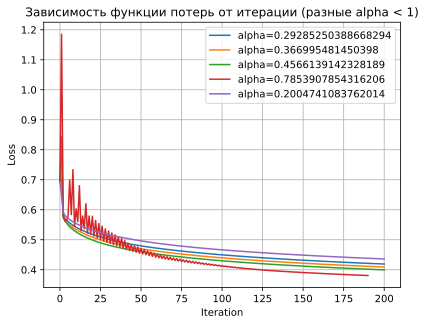

In [342]:
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

plt.figure()
for alpha, history in results[0:5]:
    plt.plot(range(len(history['func'])), history['func'], label=f'alpha={alpha}')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Зависимость функции потерь от итерации (разные alpha < 1)')
plt.legend()
plt.grid(True)
plt.savefig('4_exp1.pdf')
plt.show()

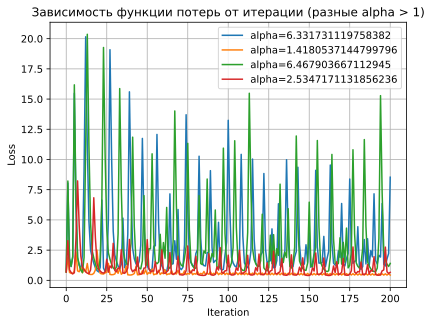

<Figure size 640x480 with 0 Axes>

In [322]:
plt.figure()
for alpha, history in results[6:]:
    plt.plot(range(len(history['func'])), history['func'], label=f'alpha={alpha}')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Зависимость функции потерь от итерации (разные alpha > 1)')
plt.legend()
plt.grid(True)
plt.show()
plt.savefig('4_exp2.pdf')

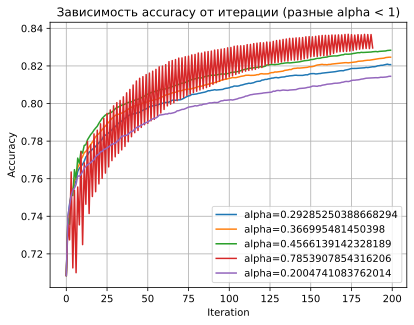

In [344]:
plt.figure()
for alpha, history in results[:5]:
    plt.plot(range(len(history['accuracy'])), history['accuracy'], label=f'alpha={alpha}')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Зависимость accuracy от итерации (разные alpha < 1)')
plt.legend()
plt.grid(True)
plt.savefig('4_exp3.pdf')
plt.show()

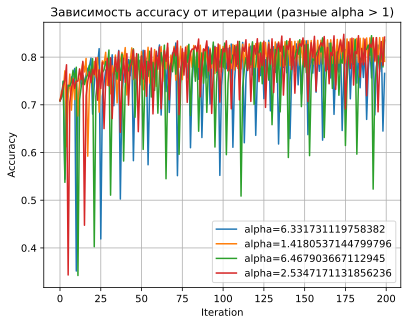

In [343]:
plt.figure()
for alpha, history in results[6:]:
    plt.plot(range(len(history['accuracy'])), history['accuracy'], label=f'alpha={alpha}')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Зависимость accuracy от итерации (разные alpha > 1)')
plt.legend()
plt.grid(True)
plt.savefig('4_exp4.pdf')
plt.show()

In [220]:
best_alpha = alphas[0]

## От step_beta

In [221]:
betas = [0, 1, 2, 3, 4, 5, 6, 8, 10, 50]

results_betas = []

In [222]:
for i, beta in enumerate(betas, start=1):
    classifier = GDClassifier('binary_logistic', step_alpha=0.1,
                           step_beta=beta, max_iter=200, l2_coef=0.001)
    history = classifier.fit(X=X_train, y=y_train, w_0=np.zeros(X_train.shape[1]),
                             trace=True, X_test=X_test, y_test=y_test)
    results_betas.append((beta, history))
    print(f'Step {i}, beta={beta}')

Step 1, beta=0
Step 2, beta=1
Step 3, beta=2
Step 4, beta=3
Step 5, beta=4
Step 6, beta=5
Step 7, beta=6
Step 8, beta=8
Step 9, beta=10
Step 10, beta=50


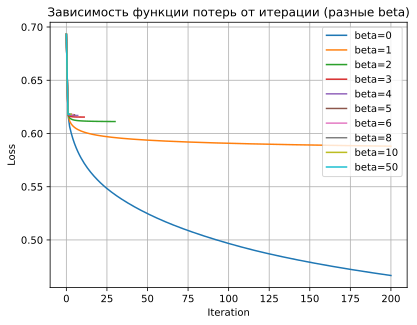

In [345]:
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

plt.figure()
for beta, history in results_betas:
    plt.plot(range(len(history['func'])), history['func'], label=f'beta={beta}')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Зависимость функции потерь от итерации (разные beta)')
plt.legend()
plt.grid(True)
plt.savefig('4_exp5.pdf')
plt.show()

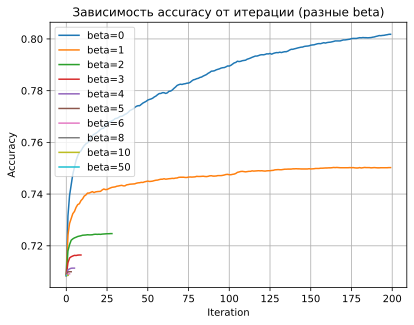

In [346]:
plt.figure()
for beta, history in results_betas:
    plt.plot(range(len(history['accuracy'])), history['accuracy'], label=f'beta={beta}')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Зависимость accuracy от итерации (разные beta)')
plt.legend()
plt.grid(True)
plt.savefig('4_exp6.pdf')
plt.show()

In [225]:
best_beta = betas[0]

## От начального приближения

In [226]:
# зафиксируем альфа и бета
alpha = 0.1
beta = 1

# несколько начальных приближений
weights_0 = [
    np.zeros(X_train.shape[1]),                    # все нули
    np.ones(X_train.shape[1]),                     # все единицы
    np.random.normal(0, 1, X_train.shape[1]),      # нормальное распределение
    np.random.uniform(-1, 1, X_train.shape[1]),    # равномерное распределение
    np.random.normal(0, 0.1, X_train.shape[1])     # малый разброс
]

results_w0 = []

In [227]:
for i, w0 in enumerate(weights_0, start=1):
    classifier = GDClassifier('binary_logistic', step_alpha=alpha,
                           step_beta=beta, max_iter=200, l2_coef=0.001)
    history = classifier.fit(X=X_train, y=y_train, w_0=w0,
                             trace=True, X_test=X_test, y_test=y_test)
    results_w0.append((i, history))
    print(f'Step {i}, w_0={list(w0)}')

Step 1, w_0=[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), n

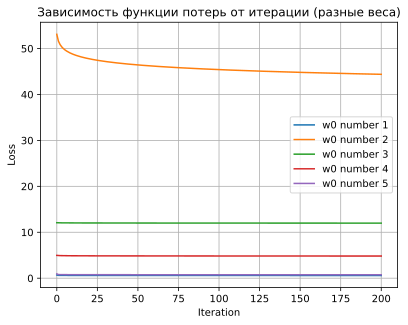

In [347]:
plt.figure()
for i, history in results_w0:
    plt.plot(range(len(history['func'])), history['func'], label=f'w0 number {i}')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Зависимость функции потерь от итерации (разные веса)')
plt.legend()
plt.grid(True)
plt.savefig('4_exp7.pdf')
plt.show()

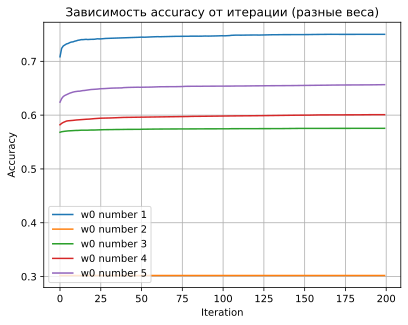

In [348]:
plt.figure()
for i, history in results_w0:
    plt.plot(range(len(history['accuracy'])), history['accuracy'], label=f'w0 number {i}')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Зависимость accuracy от итерации (разные веса)')
plt.legend()
plt.grid(True)
plt.savefig('4_exp8.pdf')
plt.show()

In [230]:
# лучшее начальное приближение == 0
w0_best = weights_0[0]

# Эксперимент 5: исследование поведения стохастического градиентного спуска от различных параметров

Исследуйте поведение стохастического градиентного спуска для задачи логистической регрессии в зависимости от следующих параметров:

• параметр размера шага step_alpha

• параметр размера шага step_beta

• размер подвыборки batch_size

• начального приближения


## По step_alpha

In [231]:
alphas_small_stoch = np.random.uniform(0.001, 1, 5)   # 5 случайных < 1
alphas_big_stoch   = np.random.uniform(1, 10, 5)      # 5 случайных > 1
alphas_stoch = sorted(np.concatenate([alphas_small, alphas_big]))

results_stoch = []
alphas_stoch

[np.float64(0.2004741083762014),
 np.float64(0.29285250388668294),
 np.float64(0.366995481450398),
 np.float64(0.4566139142328189),
 np.float64(0.7853907854316206),
 np.float64(1.4180537144799796),
 np.float64(2.5347171131856236),
 np.float64(5.628109945722504),
 np.float64(6.331731119758382),
 np.float64(6.467903667112945)]

In [232]:
for i, alpha in enumerate(alphas_stoch, start=1):
    classifier = SGDClassifier('binary_logistic', batch_size=500,
                               step_alpha=alpha, step_beta=0, max_iter=200, l2_coef=0.001)
    history = classifier.fit(X=X_train, y=y_train, w_0=np.zeros(X_train.shape[1]),
                             trace=True, X_test=X_test, y_test=y_test)
    results_stoch.append([alpha, history])
    print(f'Step {i}, alpha={alpha:.3f}')

Step 1, alpha=0.200
Step 2, alpha=0.293
Step 3, alpha=0.367
Step 4, alpha=0.457
Step 5, alpha=0.785
Step 6, alpha=1.418
Step 7, alpha=2.535
Step 8, alpha=5.628
Step 9, alpha=6.332
Step 10, alpha=6.468


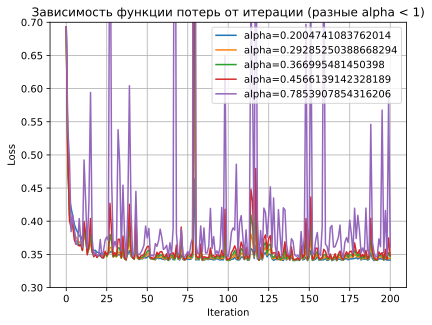

In [349]:
plt.figure()
plt.ylim([0.3, 0.7])
for alpha, history in results_stoch[0:5]:
    plt.plot(range(len(history['func'])), history['func'], label=f'alpha={alpha}')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Зависимость функции потерь от итерации (разные alpha < 1)')
plt.legend()
plt.grid(True)
plt.savefig('5_exp1.pdf')
plt.show()

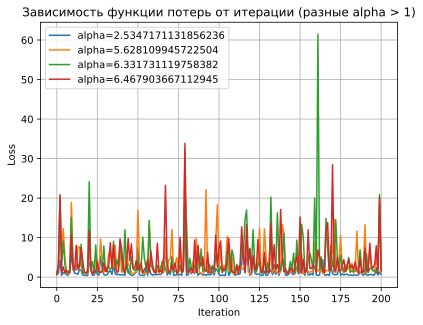

In [350]:
plt.figure()
for alpha, history in results_stoch[6:]:
    plt.plot(range(len(history['func'])), history['func'], label=f'alpha={alpha}')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Зависимость функции потерь от итерации (разные alpha > 1)')
plt.legend()
plt.grid(True)
plt.savefig('5_exp2.pdf')
plt.show()

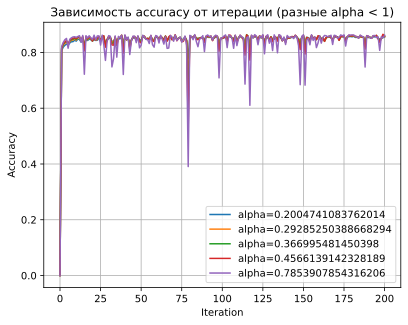

In [351]:
plt.figure()
for alpha, history in results_stoch[:5]:
    plt.plot(range(len(history['accuracy'])), history['accuracy'], label=f'alpha={alpha}')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Зависимость accuracy от итерации (разные alpha < 1)')
plt.legend()
plt.grid(True)
plt.savefig('5_exp3.pdf')
plt.show()

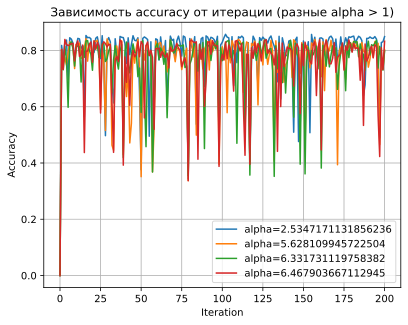

In [352]:
plt.figure()
for alpha, history in results_stoch[6:]:
    plt.plot(range(len(history['accuracy'])), history['accuracy'], label=f'alpha={alpha}')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Зависимость accuracy от итерации (разные alpha > 1)')
plt.legend()
plt.grid(True)
plt.savefig('5_exp4.pdf')
plt.show()

In [237]:
best_alpha_stoch = alphas_stoch[0]

## По step_beta

In [238]:
betas_stoch = [0, 1, 2, 3, 4, 5, 6, 8, 10, 50]
results_betas_stoch = []

In [239]:
for i, beta in enumerate(betas, start=1):
    classifier = SGDClassifier('binary_logistic', batch_size=500,
                               step_alpha=0.1, step_beta=beta, max_iter=200, l2_coef=0.001)
    history = classifier.fit(X=X_train, y=y_train, w_0=np.zeros(X_train.shape[1]),
                             trace=True, X_test=X_test, y_test=y_test)
    results_betas_stoch.append((beta, history))
    print(f'Step {i}, beta={beta}')

Step 1, beta=0
Step 2, beta=1
Step 3, beta=2
Step 4, beta=3
Step 5, beta=4
Step 6, beta=5
Step 7, beta=6
Step 8, beta=8
Step 9, beta=10
Step 10, beta=50


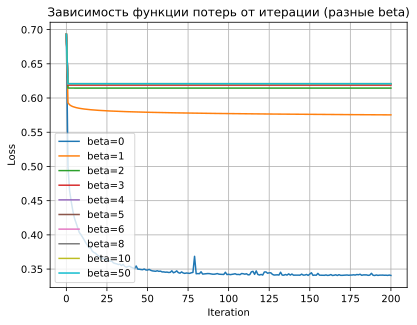

In [353]:
plt.figure()
for beta, history in results_betas_stoch:
    plt.plot(range(len(history['func'])), history['func'], label=f'beta={beta}')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Зависимость функции потерь от итерации (разные beta)')
plt.legend()
plt.grid(True)
plt.savefig('5_exp5.pdf')
plt.show()

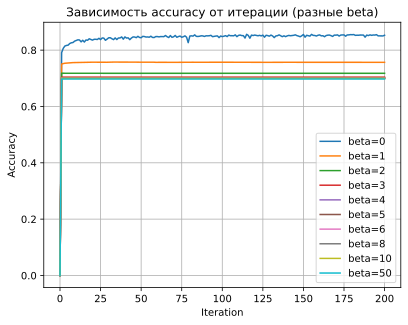

In [354]:
plt.figure()
for beta, history in results_betas_stoch:
    plt.plot(range(len(history['accuracy'])), history['accuracy'], label=f'beta={beta}')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Зависимость accuracy от итерации (разные beta)')
plt.legend()
plt.grid(True)
plt.savefig('5_exp6.pdf')
plt.show()

In [242]:
best_beta_stoch = betas_stoch[0]

## От начального приближения

In [243]:
# зафиксируем альфа и бета
alpha_stoch = best_alpha_stoch
beta_stoch = best_beta_stoch

# несколько начальных приближений
weights_0_stoch = [
    np.zeros(X_train.shape[1]),                    # все нули
    np.ones(X_train.shape[1]),                     # все единицы
    np.random.normal(0, 1, X_train.shape[1]),      # нормальное распределение
    np.random.uniform(-1, 1, X_train.shape[1]),    # равномерное распределение
    np.random.normal(0, 0.1, X_train.shape[1])     # малый разброс
]

results_w0_stoch = []

In [244]:
for i, w0 in enumerate(weights_0_stoch, start=1):
    classifier = SGDClassifier('binary_logistic', batch_size=500,
                               step_alpha=alpha_stoch, step_beta=beta_stoch, max_iter=200, l2_coef=0.001)
    history = classifier.fit(X=X_train, y=y_train, w_0=w0,
                             trace=True, X_test=X_test, y_test=y_test)
    results_w0_stoch.append((i, history))
    print(f'Step {i}, w_0={list(w0)}')

Step 1, w_0=[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), n

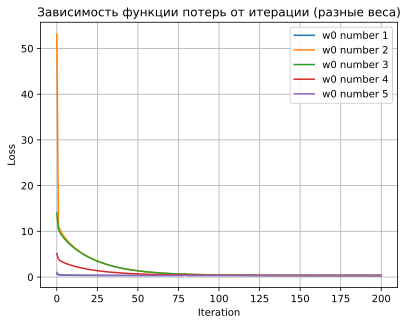

In [355]:
plt.figure()
for i, history in results_w0_stoch:
    plt.plot(range(len(history['func'])), history['func'], label=f'w0 number {i}')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Зависимость функции потерь от итерации (разные веса)')
plt.legend()
plt.grid(True)
plt.savefig('5_exp7.pdf')
plt.show()

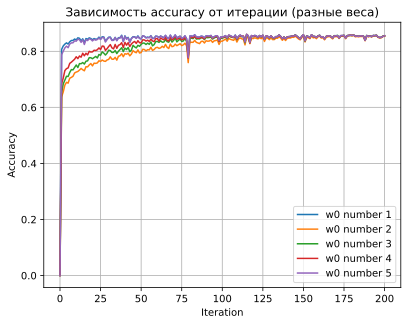

In [356]:
plt.figure()
for i, history in results_w0_stoch:
    plt.plot(range(len(history['accuracy'])), history['accuracy'], label=f'w0 number {i}')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Зависимость accuracy от итерации (разные веса)')
plt.legend()
plt.grid(True)
plt.savefig('5_exp8.pdf')
plt.show()

In [247]:
# лучшее начальное приближение == 0
w0_best_stoch = weights_0[0]

## По batch_size

In [248]:
batch_sizes = [50, 100, 200, 300, 400, 500, 1000, 2000, 3000]
results_batch_sizes = []

In [249]:
for i, bs in enumerate(batch_sizes, start=1):
    classifier = SGDClassifier('binary_logistic', batch_size=bs,
                               step_alpha=best_alpha_stoch,
                               step_beta=best_beta_stoch,
                               max_iter=200, l2_coef=0.001)
    history = classifier.fit(X=X_train, y=y_train, w_0=np.zeros(X_train.shape[1]),
                             trace=True, X_test=X_test, y_test=y_test)
    results_batch_sizes.append((bs, history))
    print(f'Step {i}, batch size={bs}')

Step 1, batch size=50
Step 2, batch size=100
Step 3, batch size=200
Step 4, batch size=300
Step 5, batch size=400
Step 6, batch size=500
Step 7, batch size=1000
Step 8, batch size=2000
Step 9, batch size=3000


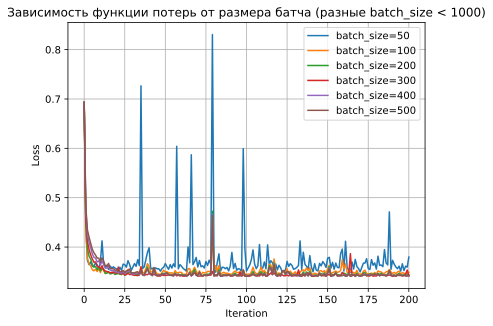

In [357]:
plt.figure()
for bs, history in results_batch_sizes[:6]:
    plt.plot(range(len(history['func'])), history['func'], label=f'batch_size={bs}')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Зависимость функции потерь от размера батча (разные batch_size < 1000)')
plt.legend()
plt.grid(True)
plt.savefig('5_exp9.pdf')
plt.show()

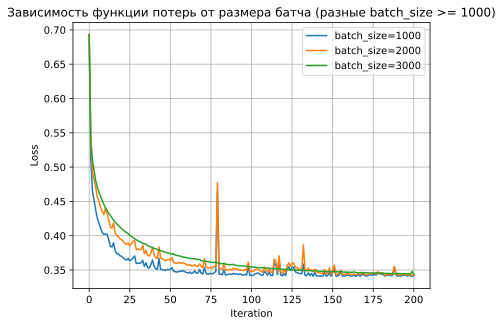

In [358]:
plt.figure()
for bs, history in results_batch_sizes[6:]:
    plt.plot(range(len(history['func'])), history['func'], label=f'batch_size={bs}')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Зависимость функции потерь от размера батча (разные batch_size >= 1000)')
plt.legend()
plt.grid(True)
plt.savefig('5_exp10.pdf')
plt.show()

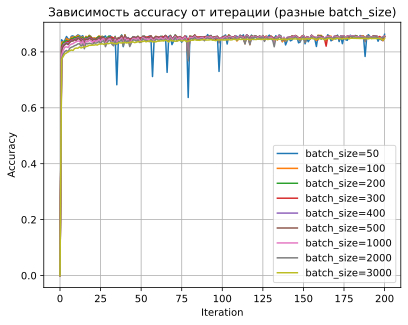

In [359]:
plt.figure()
for bs, history in results_batch_sizes:
    plt.plot(range(len(history['accuracy'])), history['accuracy'], label=f'batch_size={bs}')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Зависимость accuracy от итерации (разные batch_size)')
plt.legend()
plt.grid(True)
plt.savefig('5_exp11.pdf')
plt.show()

In [253]:
best_batch_size = batch_sizes[8]

# Эксперимент 6: сравнение методов градиентного и стохастического градиентного спуска

Сравним поведение методов при лучших параметрах step_alpha, step_beta, batch_size, w_0.

In [277]:
stoch_classifier = SGDClassifier('binary_logistic', batch_size=best_batch_size,
                                 step_alpha=best_alpha_stoch, step_beta=best_beta_stoch,
                                 max_iter=200, l2_coef=0.001)
history_best_stoch = stoch_classifier.fit(X=X_train, y=y_train, w_0=w0_best_stoch,
                            trace=True, X_test=X_test, y_test=y_test)

In [278]:
grad_classifier = GDClassifier('binary_logistic', step_alpha=best_alpha, step_beta=best_beta,
                               max_iter=200, l2_coef=0.001)
history_best_grad = grad_classifier.fit(X=X_train, y=y_train, w_0=w0_best,
                            trace=True, X_test=X_test, y_test=y_test)

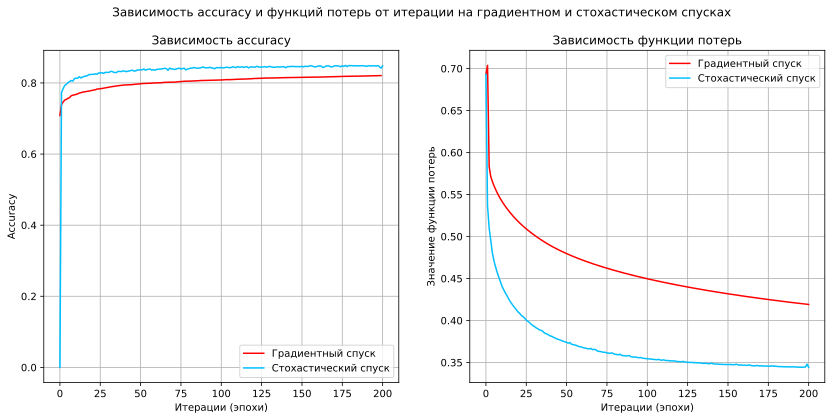

In [360]:
fig = plt.figure(figsize=(14, 6))

plt.suptitle('Зависимость accuracy и функций потерь от итерации на градиентном и стохастическом спусках')

plt.subplot(1, 2, 1)
plt.title('Зависимость accuracy')
plt.grid(True, zorder=0)
plt.xlabel("Итерации (эпохи)")
plt.ylabel("Accuracy")

plt.plot(history_best_grad['accuracy'], label='Градиентный спуск', color='red')
plt.plot(history_best_stoch['accuracy'], label='Стохастический спуск', color='deepskyblue')
plt.legend()

plt.subplot(1, 2, 2)
plt.title('Зависимость функции потерь')
plt.grid(True, zorder=0)
plt.xlabel("Итерации (эпохи)")
plt.ylabel("Значение функции потерь")

plt.plot(history_best_grad['func'], label='Градиентный спуск', color='red')
plt.plot(history_best_stoch['func'], label='Стохастический спуск', color='deepskyblue')
plt.legend()


plt.savefig('6_exp1.pdf')
plt.show()
#fig.savefig('6.pdf')
# files.download('6_exp.pdf')

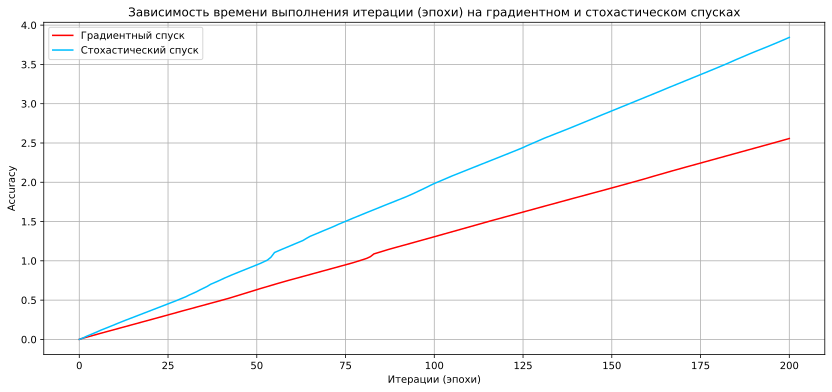

In [361]:
fig = plt.figure(figsize=(14, 6))

plt.title('Зависимость времени выполнения итерации (эпохи) на градиентном и стохастическом спусках')

plt.grid(True, zorder=0)
plt.xlabel("Итерации (эпохи)")
plt.ylabel("Accuracy")

plt.plot(history_best_grad['time'], label='Градиентный спуск', color='red')
plt.plot(history_best_stoch['time'], label='Стохастический спуск', color='deepskyblue')
plt.legend()

fig.savefig('6_exp_time.pdf')
plt.show()
# files.download('6_exp_time.pdf')

# Эксперимент 7: лемматизация

Примените алгоритм лемматизации (например, WordNetLemmatizer из библотеки nltk) к коллекции. Удалите из текста стоп-слова (например, используя список стоп-слов из nltk). Исследуйте, как предобработка корпуса повлияла на точность классификации, время работы алгоритма и размерность признакового про- странства.

In [258]:
!pip install nltk

In [259]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/peskovakar/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/peskovakar/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/peskovakar/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/peskovakar/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/peskovakar/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/peskovakar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [260]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk import pos_tag, word_tokenize

lemmatizer = WordNetLemmatizer()

def get_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN
    
def lemmatize_text(text):
    if not isinstance(text, str):
        return ""
    tokens = word_tokenize(text)
    tagged_text = pos_tag(tokens)
    lemmatized = [
        lemmatizer.lemmatize(word, get_pos(tag))
        for word, tag in tagged_text
    ]
    return " ".join(lemmatized)
        

In [261]:
comms_train_lem = comms_train.apply(lemmatize_text)
comms_test_lem = comms_test.apply(lemmatize_text)

In [262]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

comms_train_clean = comms_train_lem.apply(
    lambda text: " ".join([word for word in text.split() if word not in stop_words])
)
comms_test_clean = comms_test_lem.apply(
    lambda text: " ".join([word for word in text.split() if word not in stop_words])
)

In [263]:
comms_test_clean.head(5)

0    thank understand think highly would revert wit...
1                               dear god site horrible
2    somebody invariably try add religion really me...
3    say right type type institution need case thre...
4    add new product list make sure relevant add ne...
Name: comment_text, dtype: object

In [264]:
comms_test_lem.head(5)

0    thank you for understand i think very highly o...
1                       dear god this site be horrible
2    somebody will invariably try to add religion r...
3    it say it right there that it be a type the ty...
4    before add a new product to the list make sure...
Name: comment_text, dtype: object

In [266]:
X_train_new = vec.fit_transform(comms_train_clean)
X_test_new = vec.transform(comms_test_clean)

In [268]:
print(X_train.shape, X_train_new.shape, X_train.shape[1] - X_train_new.shape[1])

(52061, 18252) (52061, 14694) 3558


Исследуем, как такая предобработка повлияла на точность классификации, время работы алгоритма и размерность признакового пространства. Использовать будем метод стохастического градиентного спуска, так как он показал результаты лучше.

In [275]:
stoch_classifier_lem = SGDClassifier('binary_logistic', batch_size=best_batch_size,
                                     step_alpha=best_alpha_stoch, step_beta=best_beta_stoch,
                                     max_iter=200, l2_coef=0.001)

history_stoch_lem = stoch_classifier_lem.fit(X=X_train_new, y=y_train,
                                              w_0=np.zeros(X_train_new.shape[1]),
                                              trace=True, X_test=X_test_new, y_test=y_test)

In [274]:
classifier_lem = GDClassifier('binary_logistic', step_alpha=best_alpha_stoch, step_beta=best_beta_stoch,
                                     max_iter=200, l2_coef=0.001)

history_grad_lem = classifier_lem.fit(X=X_train_new, y=y_train,
                                              w_0=np.zeros(X_train_new.shape[1]),
                                              trace=True, X_test=X_test_new, y_test=y_test)

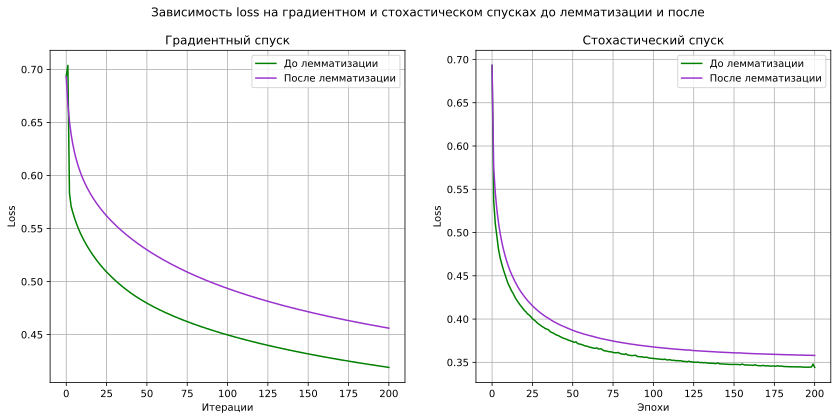

In [362]:
fig = plt.figure(figsize=(14, 6))

plt.suptitle('Зависимость loss на градиентном и стохастическом спусках до лемматизации и после')

plt.subplot(1, 2, 1)
plt.title('Градиентный спуск')
plt.grid(True, zorder=0)
plt.xlabel("Итерации")
plt.ylabel("Loss")

plt.plot(history_best_grad['func'], label='До лемматизации', color='green')
plt.plot(history_grad_lem['func'], label='После лемматизации', color='darkorchid')
plt.legend()

plt.subplot(1, 2, 2)
plt.title('Стохастический спуск')
plt.grid(True, zorder=0)
plt.xlabel("Эпохи")
plt.ylabel("Loss")

plt.plot(history_best_stoch['func'], label='До лемматизации', color='green')
plt.plot(history_stoch_lem['func'], label='После лемматизации', color='darkorchid')
plt.legend()


plt.show()
fig.savefig('7_exp1.pdf')
# files.download('7_acur.pdf')

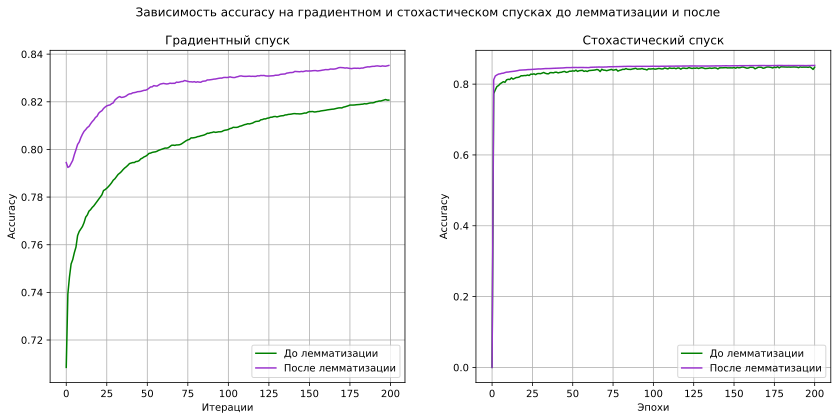

In [363]:
fig = plt.figure(figsize=(14, 6))

plt.suptitle('Зависимость accuracy на градиентном и стохастическом спусках до лемматизации и после')

plt.subplot(1, 2, 1)
plt.title('Градиентный спуск')
plt.grid(True, zorder=0)
plt.xlabel("Итерации")
plt.ylabel("Accuracy")

plt.plot(history_best_grad['accuracy'], label='До лемматизации', color='green')
plt.plot(history_grad_lem['accuracy'], label='После лемматизации', color='darkorchid')
plt.legend()

plt.subplot(1, 2, 2)
plt.title('Стохастический спуск')
plt.grid(True, zorder=0)
plt.xlabel("Эпохи")
plt.ylabel("Accuracy")

plt.plot(history_best_stoch['accuracy'], label='До лемматизации', color='green')
plt.plot(history_stoch_lem['accuracy'], label='После лемматизации', color='darkorchid')
plt.legend()


plt.show()
fig.savefig('7_exp2.pdf')
# files.download('7_acur.pdf')

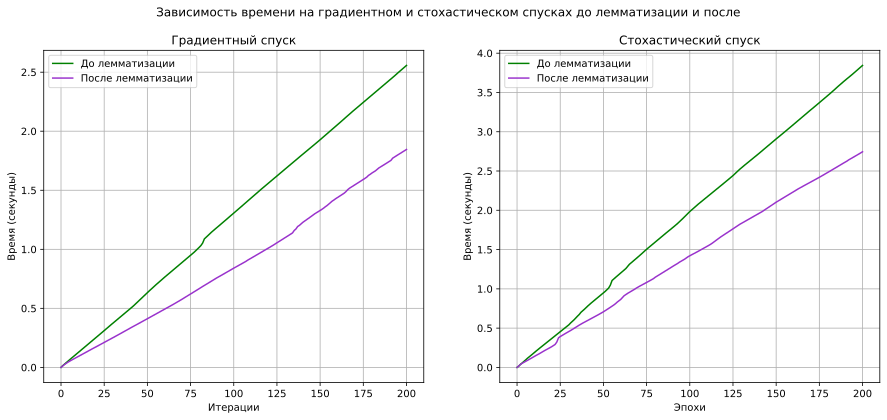

In [364]:
fig = plt.figure(figsize=(15, 6))

plt.suptitle('Зависимость времени на градиентном и стохастическом спусках до лемматизации и после')

plt.subplot(1, 2, 1)
plt.title('Градиентный спуск')
plt.grid(True, zorder=0)
plt.xlabel("Итерации")
plt.ylabel("Время (секунды)")

plt.plot(history_best_grad['time'], label='До лемматизации', color='green')
plt.plot(history_grad_lem['time'], label='После лемматизации', color='darkorchid')
plt.legend()

plt.subplot(1, 2, 2)
plt.title('Стохастический спуск')
plt.grid(True, zorder=0)
plt.xlabel("Эпохи")
plt.ylabel("Время (секунды)")

plt.plot(history_best_stoch['time'], label='До лемматизации', color='green')
plt.plot(history_stoch_lem['time'], label='После лемматизации', color='darkorchid')
plt.legend()


plt.show()
fig.savefig('7_exp3.pdf')
# files.download('7_time.pdf')

# Эксперимент 8: исследование поведения алгоритма в зависимости от параметров лемматизации.

Исследуйте качество, время работы алгоритма и размер признакового пространства в зависимости от следуюших факторов:

• использовалось представление BagOfWords или Tfidf

• параметров min_df и max_df конструкторов.

Замечание. Для построения tf-idf представления воспользуйтесь TfidfTransformer или TfidfVectorizer из библиотеки sklearn.

## Сравним использование представления BagOfWords и Tfidf

In [291]:
from sklearn.feature_extraction.text import TfidfVectorizer

vec_tfid = TfidfVectorizer(min_df=0.001)
X_train_tfid = vec_tfid.fit_transform(comms_train_clean)
X_test_tfid = vec_tfid.transform(comms_test_clean)

In [286]:
stoch_classifier_tfid = SGDClassifier('binary_logistic', batch_size=best_batch_size,
                                     step_alpha=best_alpha_stoch, step_beta=best_beta_stoch,
                                     max_iter=200, l2_coef=0.001)

history_stoch_tfid = stoch_classifier_tfid.fit(X=X_train_tfid, y=y_train,
                                              w_0=np.zeros(X_train_tfid.shape[1]),
                                              trace=True, X_test=X_test_tfid, y_test=y_test)

In [287]:
classifier_tfid = GDClassifier('binary_logistic', step_alpha=best_alpha_stoch, step_beta=best_beta_stoch,
                                     max_iter=200, l2_coef=0.001)

history_grad_tfid = classifier_tfid.fit(X=X_train_tfid, y=y_train,
                                              w_0=np.zeros(X_train_tfid.shape[1]),
                                              trace=True, X_test=X_test_tfid, y_test=y_test)

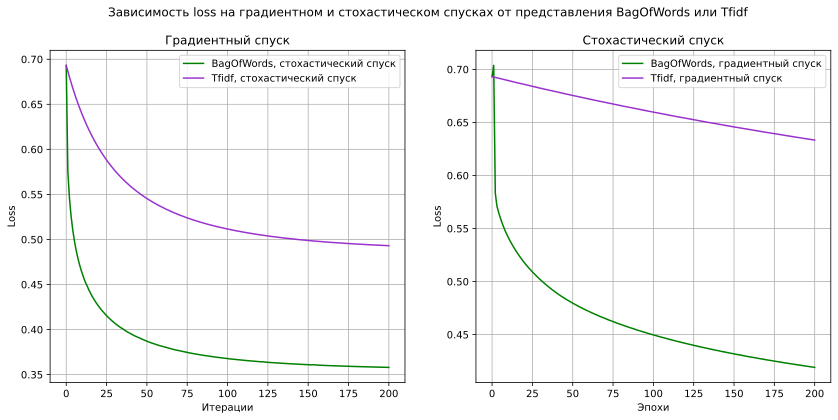

In [371]:
fig = plt.figure(figsize=(14, 6))

plt.suptitle('Зависимость loss на градиентном и стохастическом спусках от представления BagOfWords или Tfidf')

plt.subplot(1, 2, 1)
plt.title('Градиентный спуск')
plt.grid(True, zorder=0)
plt.xlabel("Итерации")
plt.ylabel("Loss")

plt.plot(history_stoch_lem['func'], label='BagOfWords, стохастический спуск', color='green')
plt.plot(history_stoch_tfid['func'], label='Tfidf, стохастический спуск', color='darkorchid')
plt.legend()

plt.subplot(1, 2, 2)
plt.title('Стохастический спуск')
plt.grid(True, zorder=0)
plt.xlabel("Эпохи")
plt.ylabel("Loss")

plt.plot(history_best_grad['func'], label='BagOfWords, градиентный спуск', color='green')
plt.plot(history_grad_tfid['func'], label='Tfidf, градиентный спуск', color='darkorchid')
plt.legend()


plt.show()
fig.savefig('8_exp1.pdf')
# files.download('7_acur.pdf')

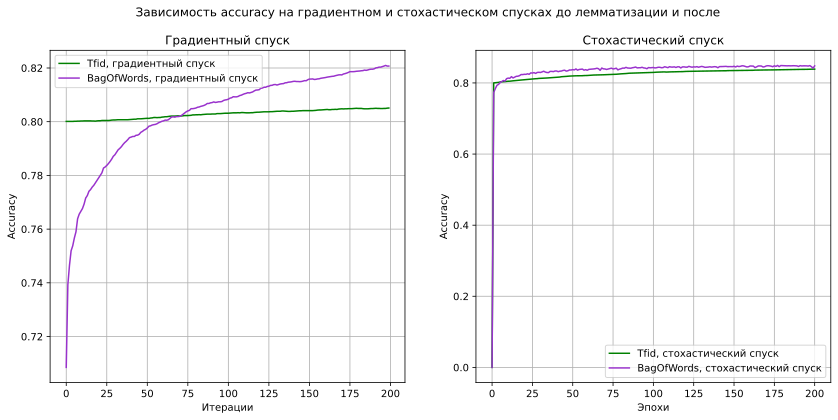

In [372]:
fig = plt.figure(figsize=(14, 6))

plt.suptitle('Зависимость accuracy на градиентном и стохастическом спусках до лемматизации и после')

plt.subplot(1, 2, 1)
plt.title('Градиентный спуск')
plt.grid(True, zorder=0)
plt.xlabel("Итерации")
plt.ylabel("Accuracy")

plt.plot(history_grad_tfid['accuracy'], label='Tfid, градиентный спуск', color='green')
plt.plot(history_best_grad['accuracy'], label='BagOfWords, градиентный спуск', color='darkorchid')
plt.legend()

plt.subplot(1, 2, 2)
plt.title('Стохастический спуск')
plt.grid(True, zorder=0)
plt.xlabel("Эпохи")
plt.ylabel("Accuracy")

plt.plot(history_stoch_tfid['accuracy'], label='Tfid, стохастический спуск', color='green')
plt.plot(history_best_stoch['accuracy'], label='BagOfWords, стохастический спуск', color='darkorchid')
plt.legend()


plt.show()
fig.savefig('8_exp2.pdf')
# files.download('7_acur.pdf')

## Зависимость от параметров min_df и max_df конструкторов.

Чем меньше min_df, тем больше признаков, а значит сложнее задача. 

In [308]:
# min_df

from sklearn.feature_extraction.text import CountVectorizer

min_dfs = [10 ** (-7), 0.0001, 0.001, 0.01, 0.1, 1]
results_min_dfs = []

for m in min_dfs:
    vectorizer = CountVectorizer(min_df=m)
    X_train = vectorizer.fit_transform(comms_train_clean)
    X_test = vectorizer.transform(comms_test_clean)

    print(f"\nmin_df = {m}, features = {X_train.shape[1]}")

    gd = GDClassifier('binary_logistic', step_alpha=best_alpha, step_beta=best_beta, max_iter=200, l2_coef=0.001)
    sgd = SGDClassifier('binary_logistic', batch_size=best_batch_size, step_alpha=best_alpha_stoch, step_beta=best_beta_stoch, max_iter=200, l2_coef=0.001)

    his_gd = gd.fit(X=X_train, y=y_train, w_0=np.zeros(X_train.shape[1]),
                             trace=True, X_test=X_test, y_test=y_test)
    his_sgd = sgd.fit(X=X_train, y=y_train, w_0=np.zeros(X_train.shape[1]),
                             trace=True, X_test=X_test, y_test=y_test)

    results_min_dfs.append((m, his_gd, his_sgd))



min_df = 1e-07, features = 80876

min_df = 0.0001, features = 12931

min_df = 0.001, features = 3023

min_df = 0.01, features = 448

min_df = 0.1, features = 17

min_df = 1, features = 80876


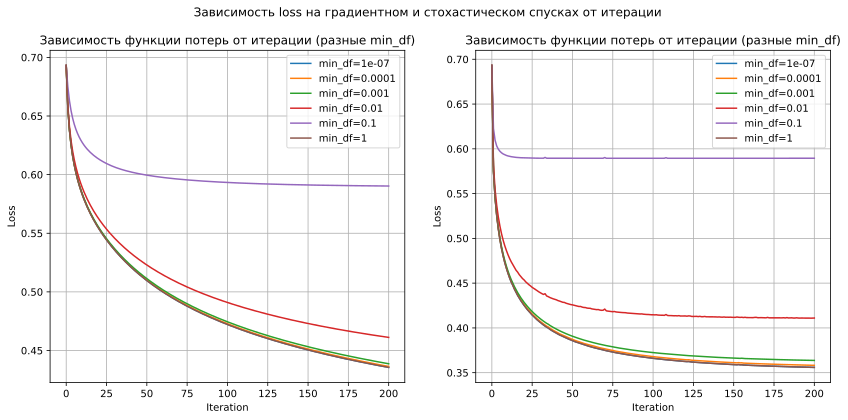

In [373]:
fig = plt.figure(figsize=(14, 6))

plt.suptitle('Зависимость loss на градиентном и стохастическом спусках от итерации')

plt.subplot(1, 2, 1)
plt.title('Градиентный спуск')
plt.grid(True, zorder=0)
plt.xlabel("Итерации")
plt.ylabel("Loss")

for m, his_gd, his_sgd in results_min_dfs:
    plt.plot(range(len(his_gd['func'])), his_gd['func'], label=f'min_df={m}')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Зависимость функции потерь от итерации (разные min_df)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.title('Стохастический спуск')
plt.grid(True, zorder=0)
plt.xlabel("Эпохи")
plt.ylabel("Loss")

for m, his_gd, his_sgd in results_min_dfs:
    plt.plot(range(len(his_sgd['func'])), his_sgd['func'], label=f'min_df={m}')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Зависимость функции потерь от итерации (разные min_df)')
plt.legend()
plt.grid(True)


plt.show()
fig.savefig('8_exp3.pdf')
# files.download('7_acur.pdf')

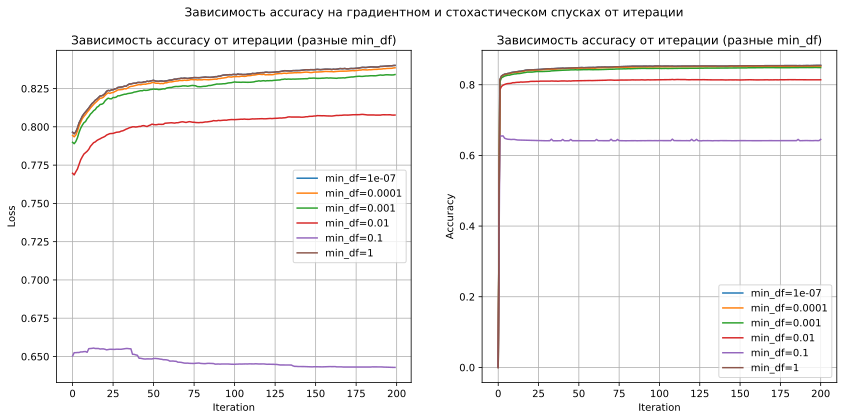

In [374]:
fig = plt.figure(figsize=(14, 6))

plt.suptitle('Зависимость accuracy на градиентном и стохастическом спусках от итерации')

plt.subplot(1, 2, 1)
plt.title('Градиентный спуск')
plt.grid(True, zorder=0)
plt.xlabel("Итерации")
plt.ylabel("Accuracy")

for m, his_gd, his_sgd in results_min_dfs:
    plt.plot(range(len(his_gd['accuracy'])), his_gd['accuracy'], label=f'min_df={m}')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Зависимость accuracy от итерации (разные min_df)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.title('Стохастический спуск')
plt.grid(True, zorder=0)
plt.xlabel("Эпохи")
plt.ylabel("Accuracy")

for m, his_gd, his_sgd in results_min_dfs:
    plt.plot(range(len(his_sgd['accuracy'])), his_sgd['accuracy'], label=f'min_df={m}')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Зависимость accuracy от итерации (разные min_df)')
plt.legend()
plt.grid(True)


plt.show()
fig.savefig('8_exp4.pdf')
# files.download('7_acur.pdf')

In [317]:
best_min_df = 10 ** (-7)

## По max_df

In [318]:
from sklearn.feature_extraction.text import CountVectorizer

max_dfs = [1.0, 0.9, 0.8, 0.7, 0.5, 0.3]
results_max_dfs = []

for m in max_dfs:
    vectorizer = CountVectorizer(max_df=m)
    X_train = vectorizer.fit_transform(comms_train_clean)
    X_test = vectorizer.transform(comms_test_clean)

    print(f"\nmax_df = {m}, features = {X_train.shape[1]}")

    gd = GDClassifier('binary_logistic', step_alpha=best_alpha, step_beta=best_beta,
                      max_iter=200, l2_coef=0.001)
    sgd = SGDClassifier('binary_logistic', batch_size=best_batch_size,
                        step_alpha=best_alpha_stoch, step_beta=best_beta_stoch,
                        max_iter=200, l2_coef=0.001)

    his_gd = gd.fit(
        X=X_train, y=y_train, w_0=np.zeros(X_train.shape[1]),
        trace=True, X_test=X_test, y_test=y_test
    )
    his_sgd = sgd.fit(
        X=X_train, y=y_train, w_0=np.zeros(X_train.shape[1]),
        trace=True, X_test=X_test, y_test=y_test
    )

    results_max_dfs.append((m, his_gd, his_sgd))



max_df = 1.0, features = 80876

max_df = 0.9, features = 80876

max_df = 0.8, features = 80876

max_df = 0.7, features = 80876

max_df = 0.5, features = 80876

max_df = 0.3, features = 80876


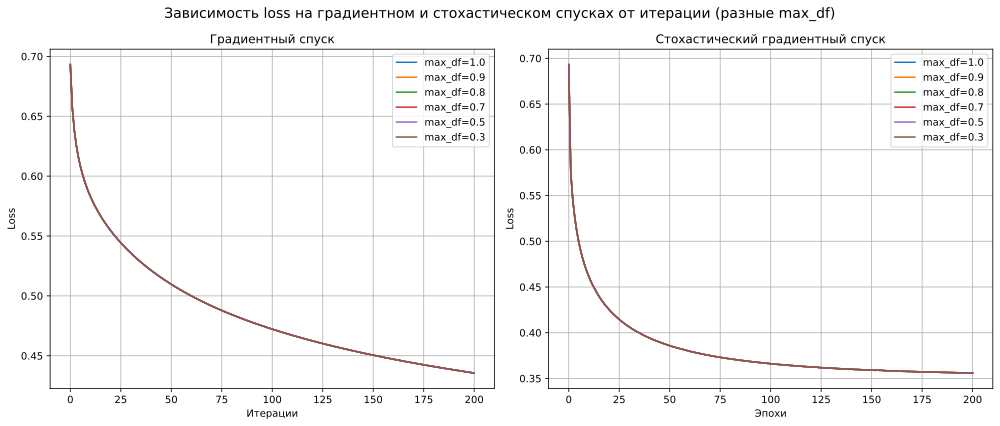

In [375]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(14, 6))
plt.suptitle('Зависимость loss на градиентном и стохастическом спусках от итерации (разные max_df)', fontsize=14)

plt.subplot(1, 2, 1)
plt.title('Градиентный спуск')
plt.grid(True, zorder=0)
plt.xlabel("Итерации")
plt.ylabel("Loss")

for m, his_gd, his_sgd in results_max_dfs:
    plt.plot(range(len(his_gd['func'])), his_gd['func'], label=f'max_df={m}')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.title('Стохастический градиентный спуск')
plt.grid(True, zorder=0)
plt.xlabel("Эпохи")
plt.ylabel("Loss")

for m, his_gd, his_sgd in results_max_dfs:
    plt.plot(range(len(his_sgd['func'])), his_sgd['func'], label=f'max_df={m}')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
fig.savefig('8_exp5.pdf')
# files.download('7_loss_maxdf.pdf')


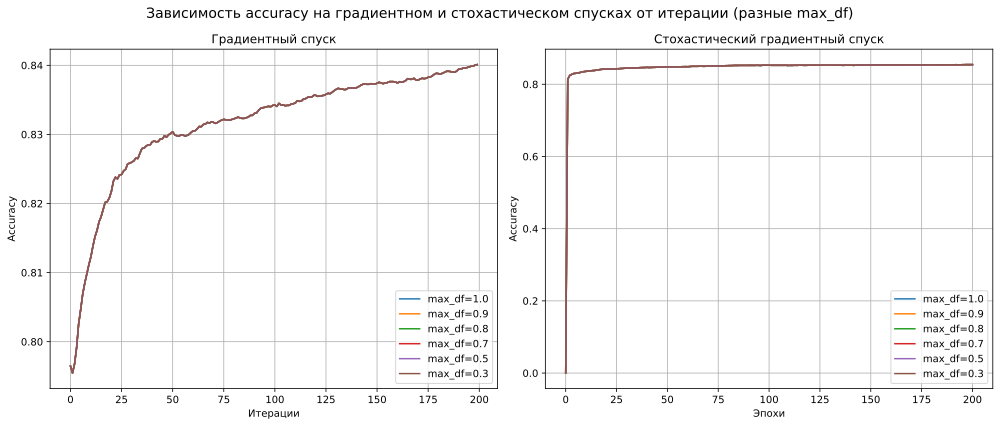

In [376]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(14, 6))

plt.suptitle('Зависимость accuracy на градиентном и стохастическом спусках от итерации (разные max_df)', fontsize=14)

# === Градиентный спуск ===
plt.subplot(1, 2, 1)
plt.title('Градиентный спуск')
plt.grid(True, zorder=0)
plt.xlabel("Итерации")
plt.ylabel("Accuracy")

for m, his_gd, his_sgd in results_max_dfs:
    plt.plot(range(len(his_gd['accuracy'])), his_gd['accuracy'], label=f'max_df={m}')
plt.legend()
plt.grid(True)

# === Стохастический спуск ===
plt.subplot(1, 2, 2)
plt.title('Стохастический градиентный спуск')
plt.grid(True, zorder=0)
plt.xlabel("Эпохи")
plt.ylabel("Accuracy")

for m, his_gd, his_sgd in results_max_dfs:
    plt.plot(range(len(his_sgd['accuracy'])), his_sgd['accuracy'], label=f'max_df={m}')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

fig.savefig('8_exp6.pdf')
# files.download('7_accuracy_maxdf.pdf')


По min_df

In [377]:
from sklearn.feature_extraction.text import CountVectorizer

min_dfs = np.logspace(-8, -1, 8)
results_min_dfs = []

for m in min_dfs:
    vectorizer = CountVectorizer(min_df=m)
    X_train = vectorizer.fit_transform(comms_train_clean)
    X_test = vectorizer.transform(comms_test_clean)

    print(f"\nmin_df = {m}, features = {X_train.shape[1]}")

    gd = GDClassifier('binary_logistic', step_alpha=best_alpha, step_beta=best_beta,
                      max_iter=200, l2_coef=0.001)
    sgd = SGDClassifier('binary_logistic', batch_size=best_batch_size,
                        step_alpha=best_alpha_stoch, step_beta=best_beta_stoch,
                        max_iter=200, l2_coef=0.001)

    his_gd = gd.fit(
        X=X_train, y=y_train, w_0=np.zeros(X_train.shape[1]),
        trace=True, X_test=X_test, y_test=y_test
    )
    his_sgd = sgd.fit(
        X=X_train, y=y_train, w_0=np.zeros(X_train.shape[1]),
        trace=True, X_test=X_test, y_test=y_test
    )

    results_min_dfs.append((m, his_gd, his_sgd))



min_df = 1e-08, features = 80876

min_df = 1e-07, features = 80876

min_df = 1e-06, features = 80876

min_df = 1e-05, features = 80876

min_df = 0.0001, features = 12931

min_df = 0.001, features = 3023

min_df = 0.01, features = 448

min_df = 0.1, features = 17


In [380]:
best_max_df = 0.5

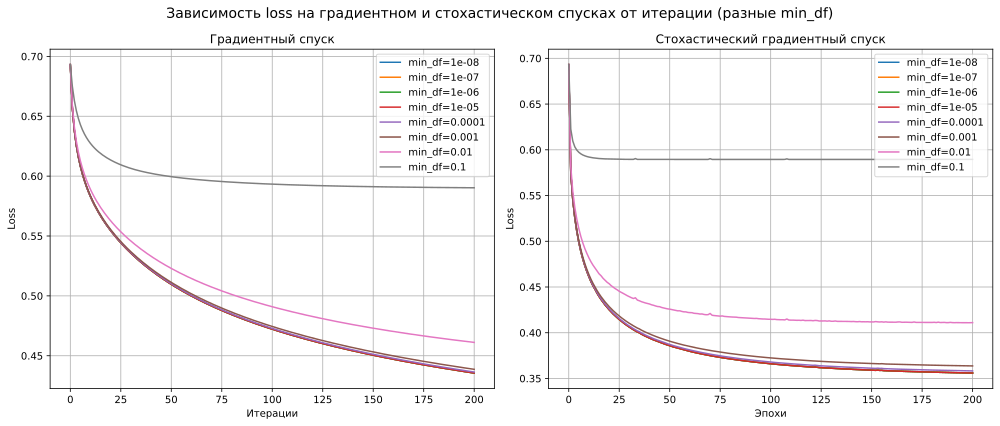

In [378]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(14, 6))
plt.suptitle('Зависимость loss на градиентном и стохастическом спусках от итерации (разные min_df)', fontsize=14)

plt.subplot(1, 2, 1)
plt.title('Градиентный спуск')
plt.grid(True, zorder=0)
plt.xlabel("Итерации")
plt.ylabel("Loss")

for m, his_gd, his_sgd in results_min_dfs:
    plt.plot(range(len(his_gd['func'])), his_gd['func'], label=f'min_df={m}')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.title('Стохастический градиентный спуск')
plt.grid(True, zorder=0)
plt.xlabel("Эпохи")
plt.ylabel("Loss")

for m, his_gd, his_sgd in results_min_dfs:
    plt.plot(range(len(his_sgd['func'])), his_sgd['func'], label=f'min_df={m}')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
fig.savefig('8_exp7.pdf')
# files.download('7_loss_maxdf.pdf')


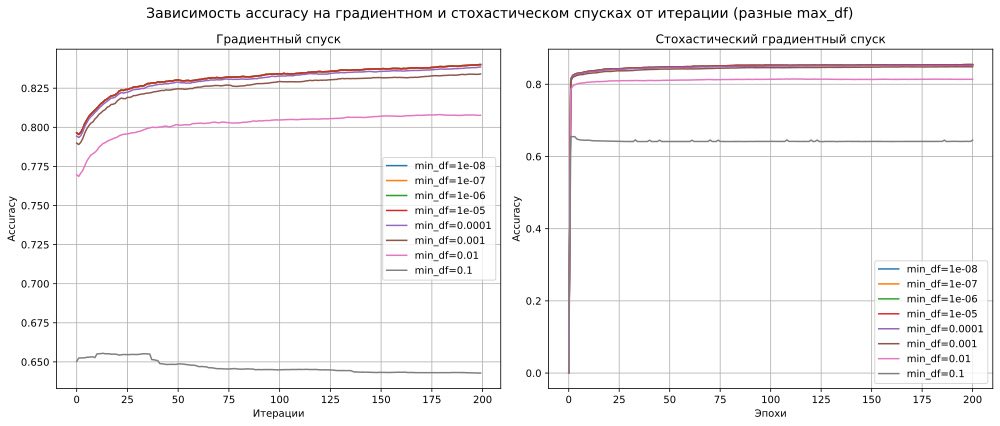

In [379]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(14, 6))

plt.suptitle('Зависимость accuracy на градиентном и стохастическом спусках от итерации (разные max_df)', fontsize=14)

# === Градиентный спуск ===
plt.subplot(1, 2, 1)
plt.title('Градиентный спуск')
plt.grid(True, zorder=0)
plt.xlabel("Итерации")
plt.ylabel("Accuracy")

for m, his_gd, his_sgd in results_min_dfs:
    plt.plot(range(len(his_gd['accuracy'])), his_gd['accuracy'], label=f'min_df={m}')
plt.legend()
plt.grid(True)

# === Стохастический спуск ===
plt.subplot(1, 2, 2)
plt.title('Стохастический градиентный спуск')
plt.grid(True, zorder=0)
plt.xlabel("Эпохи")
plt.ylabel("Accuracy")

for m, his_gd, his_sgd in results_min_dfs:
    plt.plot(range(len(his_sgd['accuracy'])), his_sgd['accuracy'], label=f'min_df={m}')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

fig.savefig('8_exp6.pdf')
# files.download('7_accuracy_maxdf.pdf')


In [381]:
best_min_df = 1e-05

# Эксперимент 9: анализ ошибок лучшего алгоритма.